SIGNATE「長期定着人材の予測」の序盤に進めた技法を、他者への展開を考慮して丁寧に整理するもの。

データはGoogleドライブに配置していることを前提とする。

In [32]:
# CatBoostと、日本語の特徴量名をグラフに出すためのライブラリのインストール
!pip install catboost japanize-matplotlib -q

In [33]:
from google.colab import drive
drive.mount('/content/drive')

# GoogleDriveのディレクトリを設定
データ置き場 = "/content/drive/MyDrive/Jaggle/syain"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# データ読み込み(shape=行数×列数。行数＝人数の確認)
入社時データ_学習 = pd.read_csv(f"{データ置き場}/employee_persona_train.csv")
入社時データ_予測 = pd.read_csv(f"{データ置き場}/employee_persona_test.csv")
月次データ_学習 = pd.read_csv(f"{データ置き場}/employee_monthly_train.csv")
月次データ_予測 = pd.read_csv(f"{データ置き場}/employee_monthly_test.csv")

print("入社時データ_学習:", 入社時データ_学習.shape)
print("入社時データ_予測:", 入社時データ_予測.shape)
print("月次データ_学習 :", 月次データ_学習.shape)
print("月次データ_予測 :", 月次データ_予測.shape)

入社時データ_学習: (2761, 20)
入社時データ_予測: (2502, 19)
月次データ_学習 : (65754, 29)
月次データ_予測 : (60048, 29)


最初にデータを俯瞰する。

- どんなパラメータを保有しているか
- trainとtestで何が違うか　とりあえず行頭・行末を５行ずつ
・・・全体感は対象ファイルをテキストで開いて確認

In [35]:
データ一覧 = {
    "入社時データ_学習": 入社時データ_学習,
    "入社時データ_予測": 入社時データ_予測,
    "月次データ_学習": 月次データ_学習,
    "月次データ_予測": 月次データ_予測,
}
for データ名, データ in データ一覧.items():
    print(f"{データ名} 行頭")
    display(データ.head(5))
    print(f"{データ名} 行末")
    display(データ.tail(5))

入社時データ_学習 行頭


,社員ID,入社日,入社区分,入社時年齢,最終学歴,専攻分野,前職経験月数,前職職種,採用経路,性別,初期職種,初期部署ID,初期勤務地,初期等級,初期役割,初任給_円,入社時メモ,上司からのフィードバック,同僚からのフィードバック,10年定着ラベル
0,E000001,2012-03-01,中途,30,大学卒,人文・教養,84,コーポレート,人材紹介,男性,コーポレート,DEP_corporate_HOKKAIDO_00,北海道,G3,シニア,312000,・経歴：大学卒（人文・教養）。中途入社で、前職・初期職種はいずれもコーポレート。\n・人物所...,担当業務に慣れた時期には、うまくいかなかった進め方を振り返る際、助言や論点の整理があると次の...,日常の共同作業では、突発対応と定例業務が重なっても優先順位と完了条件を整理し、周囲が次に動き...,1
1,E000005,2013-04-01,中途,32,大学卒,人文・教養,120,リスク・金融・コンプライアンス,直接応募,女性,リスク・金融・コンプライアンス,DEP_risk_finance_compliance_TOKYO_29,東京,G3,シニア,350000,・経歴：大学卒。人文・教養系を専攻し、中途でリスク・金融・コンプライアンス領域に入社。前職も...,入社初期から、長期的に身につけたい経験や専門領域を具体的に捉え、役割が変わった後も一つの環境...,初めて担当する業務の引継ぎでは、優先順位や完了条件を自分で整理して進めるより、周囲から手順を...,1
2,E000007,2013-01-01,中途,29,大学卒,経済・経営,84,リスク・金融・コンプライアンス,社員紹介,男性,リスク・金融・コンプライアンス,DEP_risk_finance_compliance_OSAKA_08,大阪,G2,メンバー,307000,・経歴：大学卒。経済・経営系を専攻し、中途入社。前職・初期職種ともにリスク・金融・コンプライ...,入社初期、判断に迷う案件では抱え込まず、論点を整理して上司にレビューを依頼し、確認後は関係者...,途中から引き継いだ案件では、未整理だった情報を確認して優先順位と完了条件を整理し、次に必要な...,1
3,E000008,2013-04-01,新卒,25,大学院卒,理工学,0,NaN,直接応募,男性,データ・商品企画・コンサルティング,DEP_data_product_consulting_TOKYO_04,東京,G1,メンバー,280000,・経歴：大学院（理工学）卒。新卒でデータ・商品企画・コンサルティング領域に入社。\n・人物所...,直近では、役割変更後も従来と異なる手順の意図を確認し、自ら進め方を切り替えて周囲が次の作業に...,引継ぎでは、関係者ごとに異なっていた期待を確認し、優先順位と完了条件を整理して着地点を決めた...,1
4,E000010,2011-04-01,新卒,22,大学卒,その他,0,NaN,インターン,女性,コーポレート,DEP_corporate_SENDAI_02,仙台,G1,メンバー,216000,・経歴：大学卒。新卒でコーポレート職として入社。専攻はその他。\n・人物所見：受け答え全体か...,進捗の遅れや役割変更が生じた場面では、状況を早い段階で周囲へ共有せず、上司から条件や優先順位...,引継ぎで複数の依頼が重なった際、優先順位と完了条件を整理し、周囲と進め方を合わせながら着手順...,0


入社時データ_学習 行末


,社員ID,入社日,入社区分,入社時年齢,最終学歴,専攻分野,前職経験月数,前職職種,採用経路,性別,初期職種,初期部署ID,初期勤務地,初期等級,初期役割,初任給_円,入社時メモ,上司からのフィードバック,同僚からのフィードバック,10年定着ラベル
2756,E005491,2011-10-01,中途,28,大学卒,理工学,54,営業・顧客対応,中途採用媒体,男性,営業・顧客対応,DEP_sales_client_TOKYO_09,東京,G2,メンバー,292000,・経歴：大学卒（理工学専攻）。中途入社で、前職・初期職種ともに営業・顧客対応。\n・人物所見...,育成にあたっては、学習内容を次の行動へ移すことと、方針変更時の切り替えに周囲の働きかけが必要...,部門をまたぐ依頼では、必要な情報を関係者へ早めに共有して認識を合わせ、各担当が次に動きやすい...,1
2757,E005492,2013-04-01,新卒,24,大学院卒,理工学,0,NaN,学校経由,男性,リスク・金融・コンプライアンス,DEP_risk_finance_compliance_AICHI_04,愛知,G1,メンバー,264000,・経歴：大学院卒（理工学）。新卒でリスク・金融・コンプライアンス領域に入社。\n・人物所見：...,入社初期、予定との差が生じた際には、優先順位や完了条件を自ら整理して進め方を立て直すよりも、...,繁忙時に途中参加した同僚へ作業の背景や現在の進捗を自ら共有し、引継ぎ時にも役割分担が曖昧にな...,1
2758,E005494,2012-04-01,新卒,21,専門学校卒,人文・教養,0,NaN,学校経由,男性,業務運用,DEP_operations_TOKYO_18,東京,G1,メンバー,185000,・経歴：人文・教養系の専門学校を卒業し、新卒で業務運用職として入社。\n・人物所見：受け答え...,担当や役割が変わった際、役割変更の背景や新しい進め方を自ら確認して行動を切り替える場面は限ら...,突発対応と定例業務が重なった際も、優先順位と完了条件を整理して自分から進め、周囲が次に着手し...,0
2759,E005495,2013-04-01,新卒,22,大学卒,経済・経営,0,NaN,学校経由,男性,業務運用,DEP_operations_TOKYO_23,東京,G1,メンバー,204000,・経歴：大学卒（経済・経営系）。新卒入社で、初期職種は業務運用。\n・人物所見：受け答え全体...,業務上の論点や負荷を抱えた際、本人から早い段階で相談して進め方を調整する場面は限られていた。...,引継ぎを受けた初めての業務では、条件や完了点が明確になると手順を整理して最後まで進められた一...,1
2760,E005496,2013-04-01,新卒,22,大学卒,経済・経営,0,NaN,直接応募,男性,データ・商品企画・コンサルティング,DEP_data_product_consulting_TOKYO_26,東京,G1,メンバー,236000,・経歴：大学卒（経済・経営専攻）の新卒社員。初期職種はデータ・商品企画・コンサルティング。\...,入社初期に途中から引き継いだ案件では、状況や優先順位、完了条件を自ら整理して進めるより、周囲...,急な優先順位変更の際、変更内容が明確なときは自分で必要な情報を確認して作業を切り替えた一方、...,1


入社時データ_予測 行頭


...

,社員ID,年月,経過月数,年齢,月末在籍状態,部署ID,職種,役割,等級,上司ID,...,担当プロジェクト数,顧客満足度評価,残業時間,有給取得日数,欠勤日数,研修時間,自己学習（詳細）,上司との面談実施回数,情報共有件数,在宅勤務日数
65749,E005496,2014-11-01,19,24,在籍,DEP_data_product_consulting_TOKYO_26,データ・商品企画・コンサルティング,メンバー,G1,M01453,...,2.0,3.5,9.5,1.5,0.0,11.0,受講なし,0,0,10
65750,E005496,2014-12-01,20,24,在籍,DEP_data_product_consulting_TOKYO_26,データ・商品企画・コンサルティング,メンバー,G1,M01453,...,2.0,3.5,10.5,2.0,0.0,0.0,受講なし,2,0,7
65751,E005496,2015-01-01,21,24,在籍,DEP_data_product_consulting_TOKYO_26,データ・商品企画・コンサルティング,メンバー,G1,M01453,...,1.0,3.0,17.0,0.0,0.0,0.0,BIダッシュボード作成：2.5時間,1,1,9
65752,E005496,2015-02-01,22,24,在籍,DEP_data_product_consulting_TOKYO_26,データ・商品企画・コンサルティング,メンバー,G1,M01453,...,2.0,4.0,20.0,0.0,0.0,0.0,受講なし,0,3,11
65753,E005496,2015-03-01,23,24,在籍,DEP_data_product_consulting_TOKYO_26,データ・商品企画・コンサルティング,メンバー,G1,M01453,...,1.0,3.0,16.5,0.0,0.0,0.0,受講なし,2,2,11


月次データ_予測 行頭


,社員ID,年月,経過月数,年齢,月末在籍状態,部署ID,職種,役割,等級,上司ID,...,担当プロジェクト数,顧客満足度評価,残業時間,有給取得日数,欠勤日数,研修時間,自己学習（詳細）,上司との面談実施回数,情報共有件数,在宅勤務日数
0,E000002,2015-10-01,0,33,在籍,DEP_sales_client_SENDAI_02,営業・顧客対応,シニア,G3,M00304,...,2.0,3.00,10.5,0.0,0.0,27.5,受講なし,1,0,0
1,E000002,2015-11-01,1,33,在籍,DEP_sales_client_SENDAI_02,営業・顧客対応,シニア,G3,M00304,...,2.0,3.50,12.0,0.0,0.0,13.5,受講なし,1,0,0
2,E000002,2015-12-01,2,33,在籍,DEP_sales_client_SENDAI_02,営業・顧客対応,シニア,G3,M00304,...,3.0,3.67,45.0,0.0,0.0,15.0,受講なし,3,0,1
3,E000002,2016-01-01,3,34,在籍,DEP_sales_client_SENDAI_02,営業・顧客対応,シニア,G3,M00304,...,0.0,NaN,14.5,0.0,0.0,0.0,受講なし,2,0,0
4,E000002,2016-02-01,4,34,在籍,DEP_sales_client_SENDAI_02,営業・顧客対応,シニア,G3,M00304,...,2.0,4.50,13.5,0.0,0.0,0.0,受講なし,0,0,0


月次データ_予測 行末


,社員ID,年月,経過月数,年齢,月末在籍状態,部署ID,職種,役割,等級,上司ID,...,担当プロジェクト数,顧客満足度評価,残業時間,有給取得日数,欠勤日数,研修時間,自己学習（詳細）,上司との面談実施回数,情報共有件数,在宅勤務日数
60043,E005500,2015-11-01,19,23,在籍,DEP_operations_TOKYO_20,業務運用,メンバー,G1,M00835,...,NaN,NaN,45.0,1.0,0.0,0.0,受講なし,2,4,1
60044,E005500,2015-12-01,20,23,在籍,DEP_operations_TOKYO_20,業務運用,メンバー,G1,M00835,...,NaN,NaN,18.0,0.0,0.0,0.0,受講なし,3,1,0
60045,E005500,2016-01-01,21,23,在籍,DEP_operations_TOKYO_20,業務運用,メンバー,G1,M00835,...,NaN,NaN,11.0,0.0,0.0,5.5,受講なし,1,1,1
60046,E005500,2016-02-01,22,24,在籍,DEP_operations_TOKYO_20,業務運用,メンバー,G1,M00835,...,NaN,NaN,15.5,0.0,0.0,0.0,受講なし,0,1,2
60047,E005500,2016-03-01,23,24,在籍,DEP_operations_TOKYO_20,業務運用,メンバー,G1,M00835,...,NaN,NaN,11.0,0.0,0.0,0.0,RPA基礎：3.0時間｜BIダッシュボード作成：1.5時間,1,1,1


データから「persona=1人1行」「monthly=1人複数行」の確認ができた。  
データについて追加で以下の確認を実施。  
  
１つめ：10年定着のラベルはどれくらい偏っているのか確認したい。  
２つめ：trainとtestの違いを整理したい。入社時期で分けていると思われるため入社日のレンジを確認したい。  
３つめ：monthlyの欠損確認。各人24行表記か確認したい。

In [36]:
目的変数 = "10年定着ラベル"

print(入社時データ_学習[目的変数].value_counts())
print()
print("１つめ:", 入社時データ_学習[目的変数].mean().round(4))
print()
print("２つめ train:", 入社時データ_学習["入社日"].min(), "〜", 入社時データ_学習["入社日"].max())
print("２つめ test :", 入社時データ_予測["入社日"].min(), "〜", 入社時データ_予測["入社日"].max())
print()
print("３つめ train:")
print(月次データ_学習.groupby("社員ID").size().describe())
print("３つめ test:")
print(月次データ_予測.groupby("社員ID").size().describe())

10年定着ラベル
1    1559
0    1202
Name: count, dtype: int64

１つめ: 0.5647

２つめ train: 2011-04-01 〜 2014-03-01
２つめ test : 2014-04-01 〜 2017-03-01

３つめ train:
count    2761.000000
mean       23.815284
std         1.035212
min        12.000000
25%        24.000000
50%        24.000000
75%        24.000000
max        24.000000
dtype: float64
３つめ test:
count    2502.0
mean       24.0
std         0.0
min        24.0
25%        24.0
50%        24.0
75%        24.0
max        24.0
dtype: float64


10年定着ラベルは56%なので偏りなくバラバラ。

入社日を見ると、trainとtestは入社時期でパキっと分かれていることが判明(trainが先でtestが後)。

2014年度より前に入社した人たちの情報を元に、2014年度以降に入社した人たちのデータを予測する流れ。

とりあえず、エイヤの固定値で評価するとどうなるか確認する。  
１つめ定着率0.5固定。（半分）  
２つめ定着率0.56固定。（定着ラベルどおり）.
  
  0.5でLogLossが約0.693、trainの定着率0.5647を一律に入れるとLogLossが約0.685になることを確認。

In [ ]:
定着率 = 入社時データ_学習[目的変数].mean()
正解ラベル = 入社時データ_学習[目的変数]

print(f"全員0.5   : {log_loss(正解ラベル, np.full(len(正解ラベル), 0.5)):.4f}")
print(f"全員{定着率:.4f}: {log_loss(正解ラベル, np.full(len(正解ラベル), 定着率)):.4f}")

全員0.5   : 0.6931
全員0.5647: 0.6848


personaは1人1行だが、monthlyは1人24行ある状態のため、月次データを「社員1人=1行」にすることを検討する。  


また、値を平均すると、時間経過ごとの情報が取れなくなるため、いくつかの角度から集計する。（残業20h継続と、残業5h→40hに増えた場合を区別、など）

- 数値列: 平均・標準偏差・最終月の値
- 給与: 24か月の伸び率
- 評価: 欠損率。評価が付く頻度自体が大切なのでは、という仮説。
- カテゴリ列: 最終月の部署・勤務地、異動・上司交代の回数
- 在籍状態: 休職・退職があったか

360度評価や顧客満足度は評価が更新されない月がNaNになっている。
欠損データを適当な値で埋めるのではなく、欠損を扱えるCatBoostを採用することとする。（例：0で埋めると「評価が低い」と「評価がない」の区別ができない）

「欠損」を特徴量として渡すと、「評価が付く頻度」という情報として捉えることができる。
参考URL https://qiita.com/hungryclimber/items/0c6bb122a87b23d82fb6

In [39]:
行動列 = ["残業時間", "有給取得日数", "欠勤日数", "研修時間",
        "上司との面談実施回数", "情報共有件数", "在宅勤務日数", "月例給与_円"]
評価列 = ["360度評価_親和度", "360度評価_信頼度", "360度評価_主体度",
        "360度評価_学習度", "360度評価_共有貢献度", "顧客満足度評価", "担当プロジェクト数"]

def 月次集約(月次データ: pd.DataFrame) -> pd.DataFrame:
    # first()/last()を「0か月目」「23か月目」とし、時系列順に並べて集約
    月次データ = 月次データ.sort_values(["社員ID", "経過月数"])
    社員別 = 月次データ.groupby("社員ID")
    集約結果 = pd.DataFrame(index=社員別.size().index)
    # 行動の数値列(平均=普段の水準、標準偏差=月ごとのブレ、最終月=直近の状態)
    for 列 in 行動列:
        集約結果[f"{列}_平均"] = 社員別[列].mean()
        集約結果[f"{列}_標準偏差"] = 社員別[列].std()
        集約結果[f"{列}_最終月"] = 社員別[列].last()
    # 評価の数値列(平均と、24か月のうち何割が欠損だったか)
    for 列 in 評価列:
        集約結果[f"{列}_平均"] = 社員別[列].mean()
        集約結果[f"{列}_欠損率"] = 社員別[列].apply(lambda s: s.isna().mean())

    # 給与の伸び(差額の円ではなく率にして、給与水準の違いをならす)
    初月給与 = 社員別["月例給与_円"].first()
    集約結果["給与の伸び率"] = (集約結果["月例給与_円_最終月"] - 初月給与) / 初月給与

    # カウントのみ
    集約結果["部署異動回数"] = 社員別["部署ID"].nunique() - 1
    集約結果["上司交代回数"] = 社員別["上司ID"].nunique() - 1
    集約結果["観測月数"] = 社員別.size()

    # 最終月の値をそのまま代入
    集約結果["最終月の部署ID"] = 社員別["部署ID"].last()
    集約結果["最終月の勤務地"] = 社員別["勤務地"].last()

    # 判定条件
    集約結果["休職あり"] = 社員別["月末在籍状態"].apply(lambda s: int((s == "休職").any()))
    集約結果["退職済み"] = 社員別["月末在籍状態"].apply(lambda s: int((s == "退職").any()))
    return 集約結果.reset_index()

学習データ = 入社時データ_学習.merge(月次集約(月次データ_学習), on="社員ID", how="left")
予測データ = 入社時データ_予測.merge(月次集約(月次データ_予測), on="社員ID", how="left")
# 行数が2761/2502のままなら結合事故なし。列数の差1は目的変数なので問題なし
print(学習データ.shape, 予測データ.shape)

(2761, 66) (2502, 65)


データには入社時メモ、フィードバック２種類、自己学習の詳細とテキストが4種類あることを確認。
今回のタイミングでは入社時メモに対してのみ分析を実施する。

やり方は2段階に分けて実施する。

１つめ：TF-IDF→文書を「どの文字列がどれだけ特徴的に出てくるか」の巨大な表に変換する。文字2〜4文字のかたまり(文字n-gram)で実施する。形態素分析した方がいいと思うが、時間と労力見合い。  
２つめ：SVD→テキストを10次元（列）に圧縮する。そのままモデルに渡すと過学習するので、主要な軸だけ取り出すことが目的。  
参考URL https://qiita.com/ebimontblanc/items/80938fc8f56b5a0a9217

In [40]:
# かたまりの長さ2〜4文字・10文書未満の珍しいかたまりは捨てる・語彙上限5万。いずれもエイヤなので精緻化の余地あり
ベクトル変換器 = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4),
                          min_df=10, max_features=50000)

# 学習と予測を縦につないでから変換器に学習させる。
# ラベルは使わない。
メモ全文 = pd.concat([学習データ["入社時メモ"], 予測データ["入社時メモ"]])
メモ行列 = ベクトル変換器.fit_transform(メモ全文)
print("TF-IDF行列:", メモ行列.shape)

# 特異値分解（SVD）。圧縮先の10次元はエイヤ。random_stateはいつもの。
圧縮器 = TruncatedSVD(n_components=10, random_state=27)
メモ圧縮後 = 圧縮器.fit_transform(メモ行列)

# 縦につないだ順(学習→予測)のまま返ってくるので、前半・後半で切り分けてから戻す
for 次元 in range(10):
    学習データ[f"メモsvd_{次元}"] = メモ圧縮後[:len(学習データ), 次元]
    予測データ[f"メモsvd_{次元}"] = メモ圧縮後[len(学習データ):, 次元]

TF-IDF行列: (5263, 8908)


部署IDは約460種類あり、ダミー変数化(one-hot)するとものすごい列数になるため不採用。ラベルエンコードでは真の意味付けができないものと考えて不採用とした。

そこで、カテゴリ列を列名で指定するだけで、内部で統計量に変換して扱ってくれるため、CatBoostを使用することとしている。
当初はLightGBMで組んでいたが、CatBoostに変えて部署IDを渡すとスコアが向上したため、あまり理由は考えず採用。

残りのテキスト(フィードバック2種・自己学習)と入社日は今回は使わない。今後精緻化する余地あり。
社員IDはただの通し番号なので除外。

手元の答え合わせとして交差検証(CV)を採用する。

In [46]:
# カテゴリとして扱う列
カテゴリ列 = ["入社区分", "最終学歴", "専攻分野", "前職職種", "採用経路", "性別",
         "初期職種", "初期勤務地", "初期等級", "初期役割", "初期部署ID",
         "最終月の部署ID", "最終月の勤務地"]
# モデルには渡さない列(IDは通し番号、テキストは変換済みか未使用、目的変数は答えなので厳禁)
除外列 = ["社員ID", "入社日", "入社時メモ", "上司からのフィードバック",
       "同僚からのフィードバック", 目的変数]

# CatBoostのカテゴリ列は文字列に統一し、欠損は「不明」という1つのカテゴリとして埋める
for 列 in カテゴリ列:
    学習データ[列] = 学習データ[列].fillna("不明").astype(str)
    予測データ[列] = 予測データ[列].fillna("不明").astype(str)

特徴量列 = [列 for 列 in 学習データ.columns if 列 not in 除外列]
特徴量 = 学習データ[特徴量列]
正解ラベル = 学習データ[目的変数]  # 前半で作ったものと同じ。集約後の表から取り直しているだけ
予測用特徴量 = 予測データ[特徴量列]
print(f"特徴量 {len(特徴量列)} 個")

特徴量 70 個


パラメータはほぼほぼ既定値。学習率と早期停止だけ設定して、チューニングは特にしない。
fold数の5も定番のエイヤ。

In [48]:
学習設定 = dict(
    iterations=3000,           # 木の本数上限。早期停止が途中で打ち切る前提の大きめエイヤ
    learning_rate=0.03,        # 1本の木がどれだけ強く予測を修正するか。エイヤ
    depth=6,                   # 木の深さ。定番値のエイヤ
    loss_function="Logloss",   # 学習目標　コンペ同様Logloss
    eval_metric="Logloss",     # 検証データの監視　コンペ同様Logloss
    early_stopping_rounds=100, # 検証スコアが100本連続で改善しなければ打ち切り
    random_seed=27,            # SEED値　いつもの
    verbose=0,                 # ログ停止
    allow_writing_files=False, # 作業フォルダ作成停止
)

# 交差検証。Stratified=どの分割でも定着率が56%前後になるように割ってくれる
分割器 = StratifiedKFold(n_splits=5, shuffle=True, random_state=27)

# 「学習に使っていないデータへの予測」の変数。手元スコアはこれで測る
検証予測 = np.zeros(len(特徴量))

# 提出用予測の変数。5モデルの平均をここに貯める
提出予測 = np.zeros(len(予測用特徴量))

# 学習済モデルの保管(後で特徴量重要度を見る用)
学習済モデル一覧 = []

for 分割番号, (学習行, 検証行) in enumerate(分割器.split(特徴量, 正解ラベル)):
    # Pool=CatBoost専用のデータ変数。cat_featuresで「この13列はカテゴリ」と定義
    学習プール = Pool(特徴量.iloc[学習行], 正解ラベル.iloc[学習行], cat_features=カテゴリ列)
    検証プール = Pool(特徴量.iloc[検証行], 正解ラベル.iloc[検証行], cat_features=カテゴリ列)
    モデル = CatBoostClassifier(**学習設定)
    # eval_set=検証データ。学習の止めどきを判断させる
    モデル.fit(学習プール, eval_set=検証プール)

    # predict_probaは[0の確率, 1の確率]の2列で返るので、[:, 1]=辞めていない確率を取得する
    検証予測[検証行] = モデル.predict_proba(検証プール)[:, 1]

    # 予測データには5つのfoldモデルそれぞれで予測して1/5ずつ足し込んで平均を取る
    # 時間に余裕があれば10から20で走行するとより精度があがるので、精緻化の余地あり。
    提出予測 += モデル.predict_proba(Pool(予測用特徴量, cat_features=カテゴリ列))[:, 1] / 分割器.n_splits
    学習済モデル一覧.append(モデル)
    print(f"fold{分割番号}: logloss={log_loss(正解ラベル.iloc[検証行], 検証予測[検証行]):.4f} "
          f"(木の本数={モデル.get_best_iteration()})")

print(f"\nCV logloss: {log_loss(正解ラベル, 検証予測):.4f}")

fold0: logloss=0.5109 (木の本数=634)
fold1: logloss=0.5092 (木の本数=414)
fold2: logloss=0.5152 (木の本数=405)
fold3: logloss=0.5248 (木の本数=569)
fold4: logloss=0.5223 (木の本数=517)

CV logloss: 0.5165


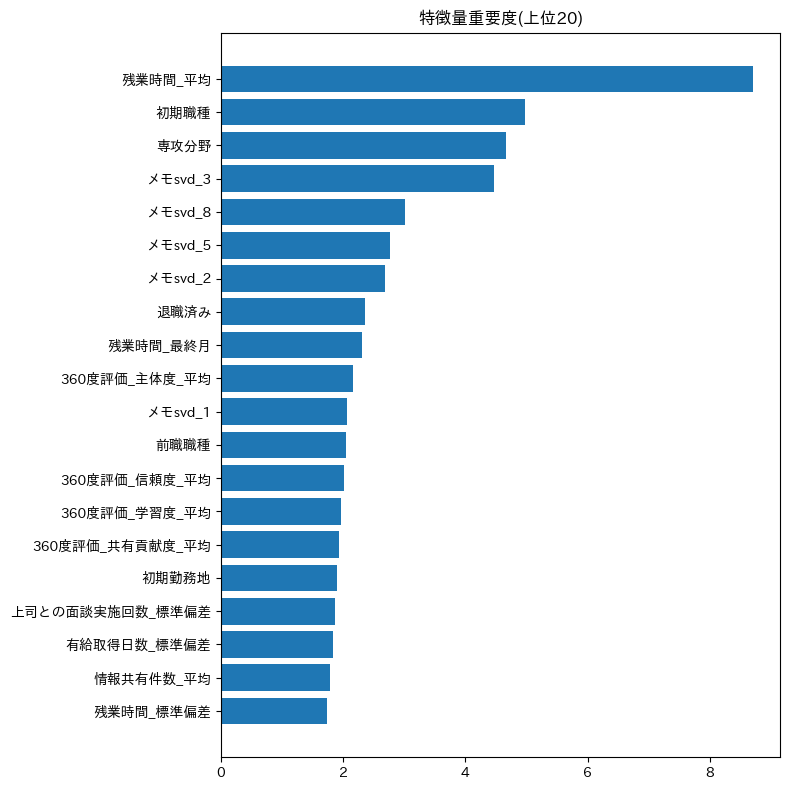

In [49]:
重要度表 = pd.DataFrame({
    "列名": 特徴量列,
    "重要度": np.mean([モデル.get_feature_importance() for モデル in 学習済モデル一覧], axis=0),
}).sort_values("重要度", ascending=False)

plt.figure(figsize=(8, 8))
plt.barh(重要度表["列名"][:20][::-1], 重要度表["重要度"][:20][::-1])
plt.title("特徴量重要度(上位20)")
plt.tight_layout()
plt.show()

給与まわり・残業時間・部署IDあたりが上位にきていることを確認。  
メモもいくつか上位にあるため、テキストにもCatBoostで利用した重要な情報があることがわかる。→形態素解説などもう少し精緻化すれば精度が上がる見込みあり。

このモデルを利用して提出用のファイルを作成する。  
ヘッダーなしで2列(社員ID、定着する確率)で出力。

In [50]:
# ヘッダー行がないためheader=None
提出見本 = pd.read_csv(f"{データ置き場}/sample_submission.csv", header=None)
提出見本.columns = ["社員ID", "見本値"]  # 見本値の列は使わない

# 見本のID順に自分の予測を並べ直す。
提出データ = 提出見本[["社員ID"]].merge(
    pd.DataFrame({"社員ID": 予測データ["社員ID"], "定着確率": 提出予測}),
    on="社員ID", how="left")
assert 提出データ["定着確率"].notna().all(), "IDが不一致"

# /contentに出力。
提出データ.to_csv("submission.csv", index=False, header=False)
print(提出データ.head())
print("行数:", len(提出データ))

      社員ID      定着確率
0  E000002  0.363084
1  E000003  0.487728
2  E000004  0.724179
3  E000006  0.608250
4  E000009  0.736695
行数: 2502
